### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### Loading and understanding the dataset

In [2]:
df = pd.read_csv('Tele-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

- Here we observe that total charges dtype is object let's change it.

In [8]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

In [9]:
# Check for duplicated entries
df.duplicated().sum()

0

In [10]:
# Check for null values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

- Here TotalCharges column has 11 missing values. Let's check this data.

#### Handling null values

In [11]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


- Even though the MonthlyCharges column is not empty,the tenure colum is 0.
- Let's delete the rows with missing values in Tenure columns since there are only 11 rows and deleting them will not affect the data.

In [12]:
df = df.drop(df[df['tenure'] == 0].index, axis=0)

- Filling missing values in TotalCharges column with the mean of TotalCharges values.

In [13]:
df = df.fillna(df['TotalCharges'].mean())

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Exploratory Data Analysis

In [15]:
# Removing redundant columns
df = df.drop('customerID',axis=1)

In [16]:
# Stats summary of numerical data
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [17]:
# Stats summary of categorical data
df.describe(include='O')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


#### Data visualization

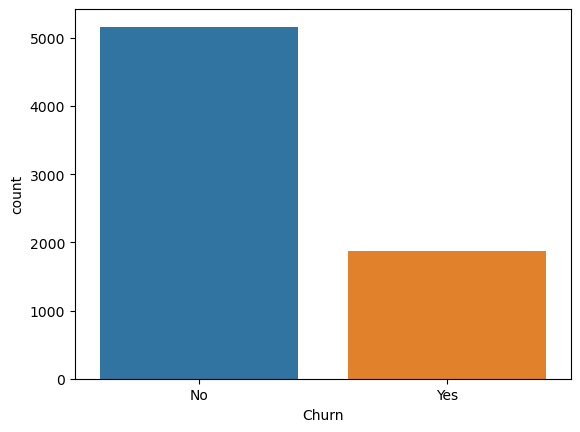

In [18]:
# Distribution of target column
sns.countplot(x=df['Churn'])
plt.show()

- Identified Class Imbalance

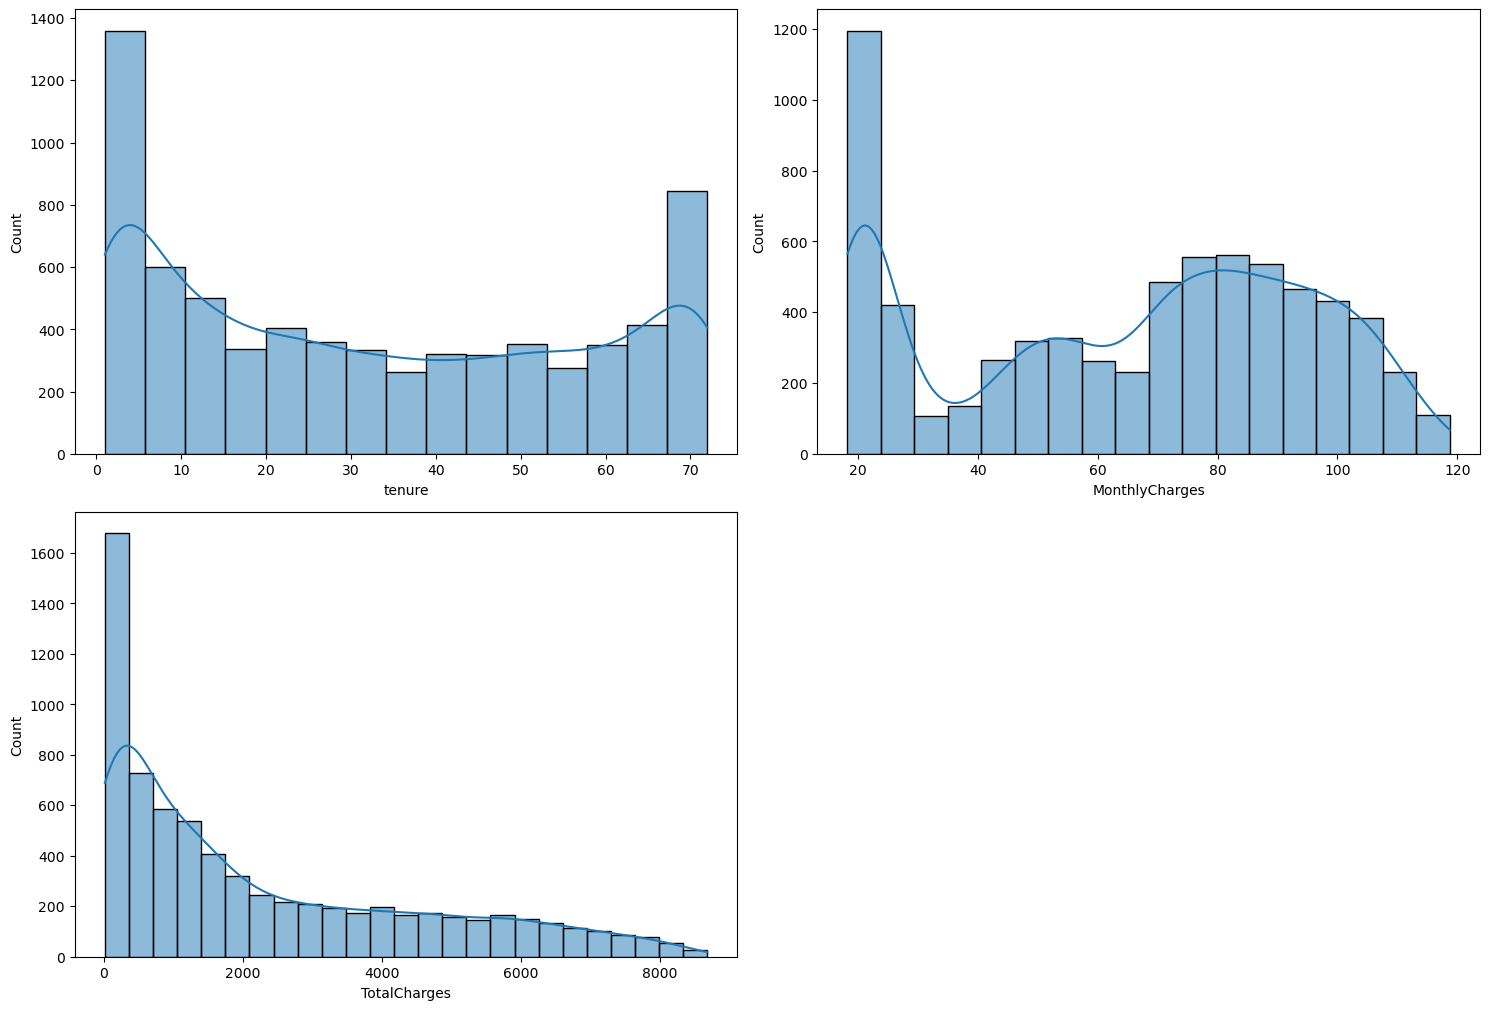

In [19]:
# Distribution of numerical columns
plt.figure(figsize=(15,50))
num_cols = ['tenure','MonthlyCharges','TotalCharges']
for i,col in enumerate(num_cols):
    plt.subplot(10,2,i+1)
    sns.histplot(x=df[col],kde=True)
plt.tight_layout()
plt.show()

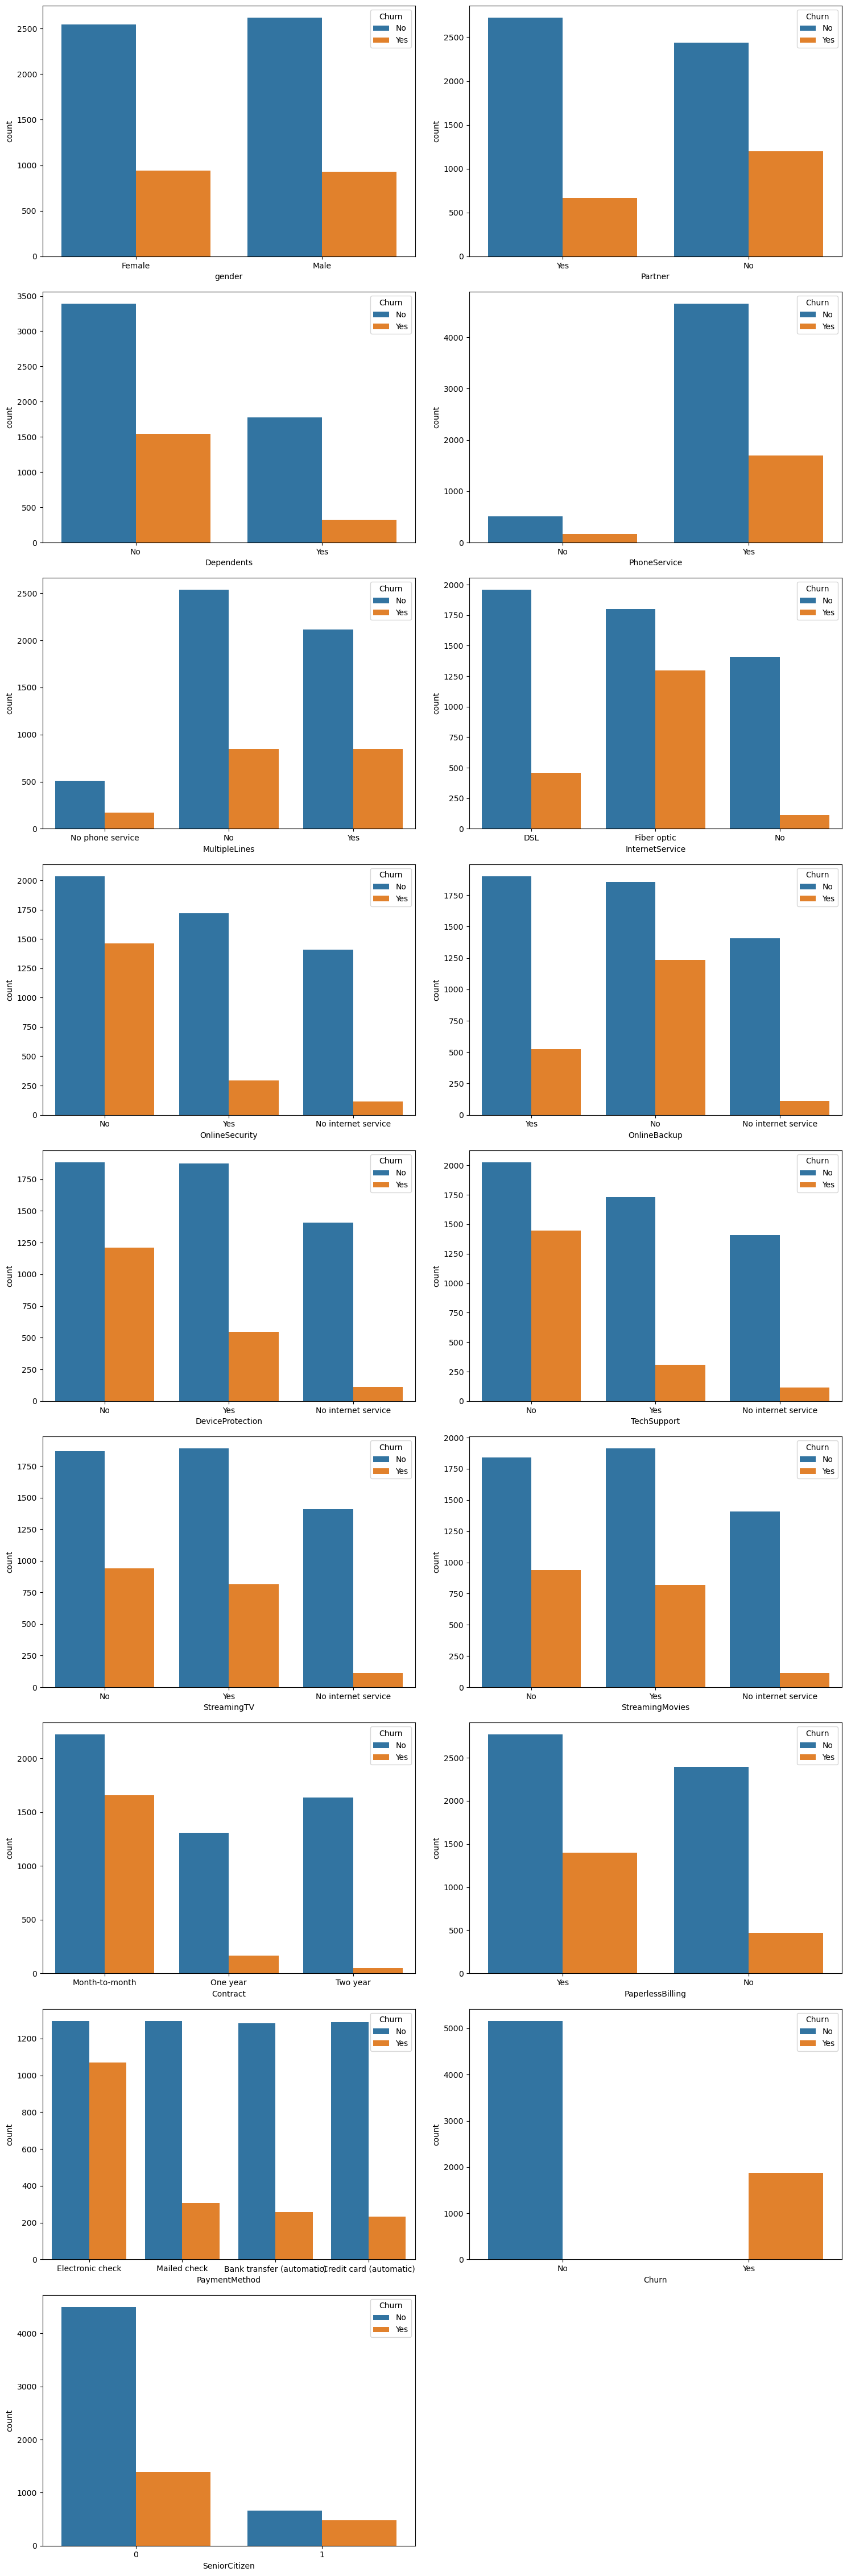

In [20]:
# Relationship between categorical features and Churn(Target)
plt.figure(figsize=(15,50))
cat_cols = [col for col in df.columns if df[col].dtype == 'object'] + ['SeniorCitizen']
for i,col in enumerate(cat_cols):
    plt.subplot(10,2,i+1)
    sns.countplot(x=df[col],hue=df['Churn'],orient='h')
plt.tight_layout()
plt.show()

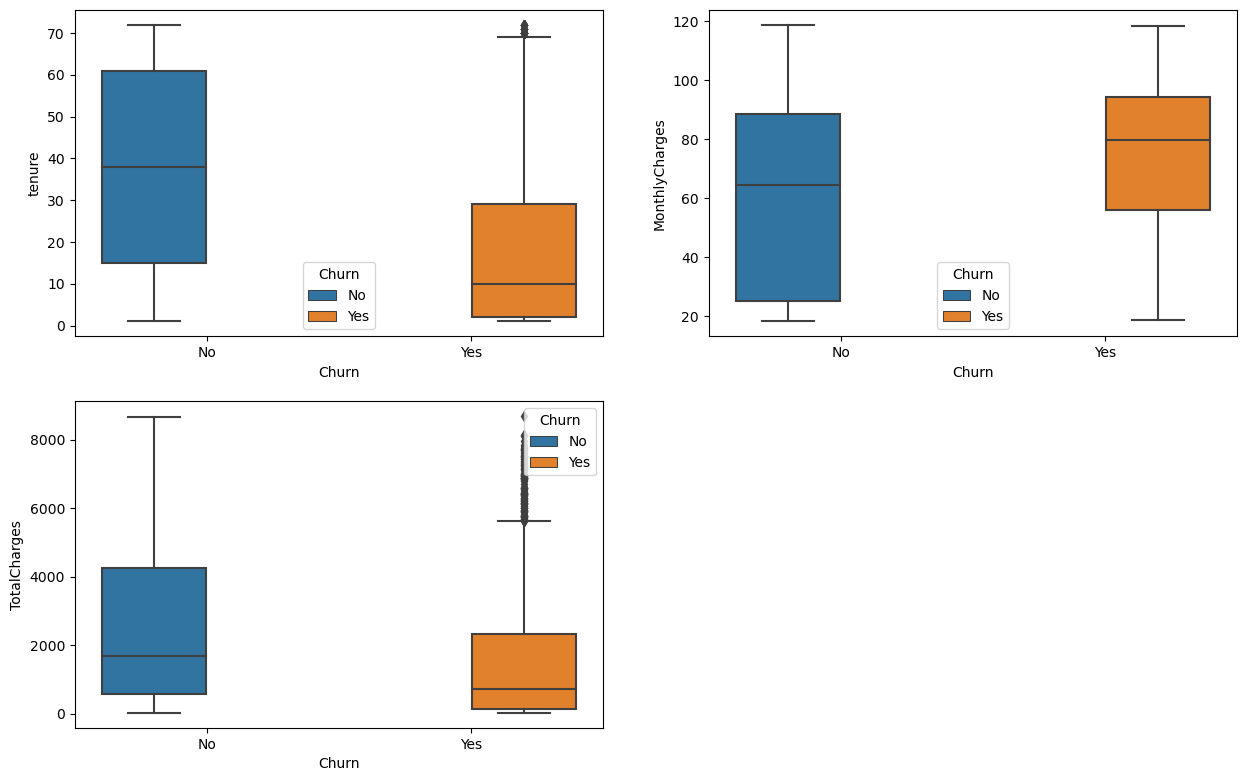

In [21]:
# Relationship between numerical features and Churn(Target)
cols = ['tenure','MonthlyCharges','TotalCharges']
plt.figure(figsize=(15,50))
for i,col in enumerate(num_cols):
    plt.subplot(10,2,i+1)
    sns.boxplot(x=df['Churn'],y=df[col],hue=df['Churn'])
plt.show()

- Customers with a longer tenure are less likely to churn.
- Higher monthly charges might drive churn due to cost dissatisfaction.
- Customers with higher total charges (long-term users) churn less.

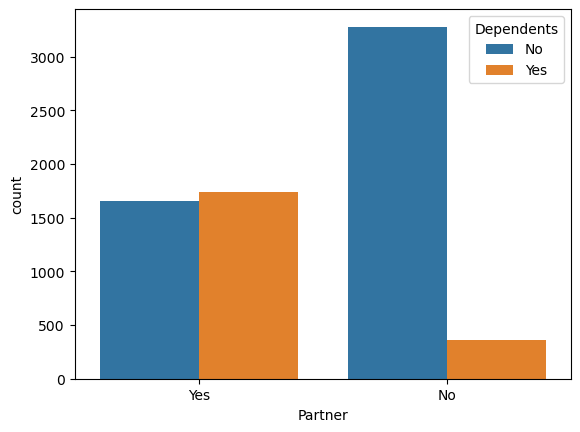

In [22]:
# Partner status and Dependents
sns.countplot(x='Partner', hue='Dependents', data=df)
plt.show()

- The number of dependents is smaller among customers without partners.

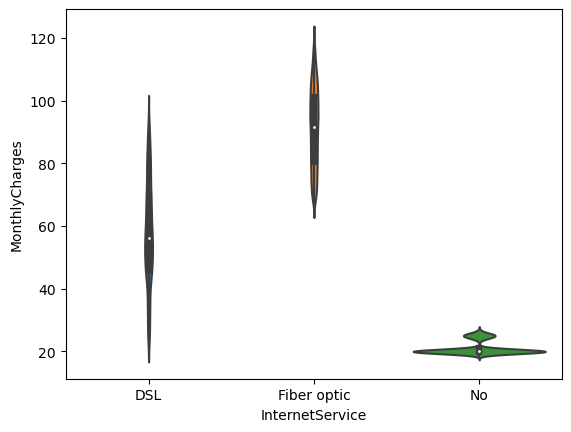

In [23]:
# InternetService and MonthlyCharges 
sns.violinplot(x='InternetService', y='MonthlyCharges', data=df)
plt.show()

- Fiber optic internet service is more expensive compared to other types of internet services.

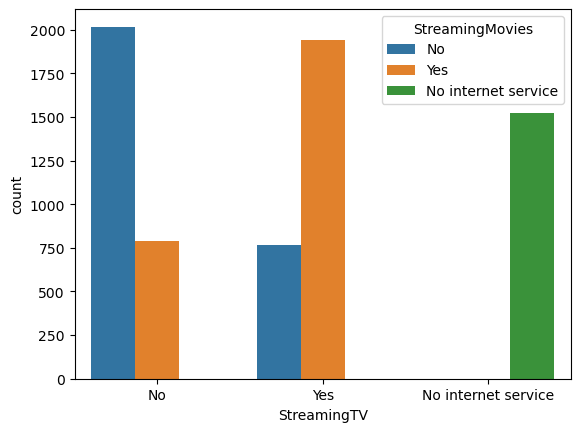

In [24]:
# StreamingTV and StreamingMovies 
sns.countplot(x='StreamingTV', hue='StreamingMovies', data=df)
plt.show()

- There is no significant difference in the distribution of StreamingTV users based on their StreamingMovies usage.

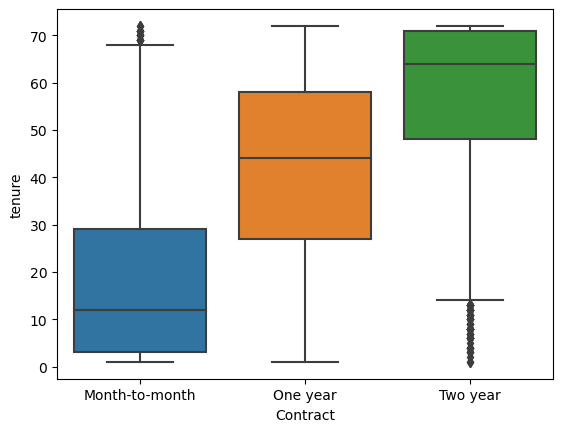

In [25]:
# Tenure Distribution by contract type
sns.boxplot(x='Contract', y='tenure', data=df)
plt.show()

- Customers with a 2-year contract tend to have a longer tenure.

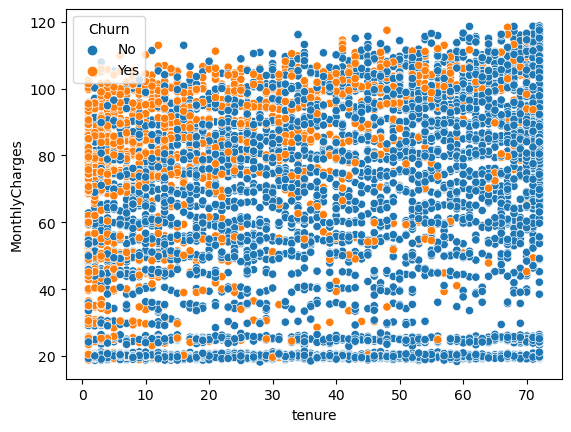

In [26]:
# Monthly charges based on tenure
sns.scatterplot(x='tenure',y='MonthlyCharges',data=df,hue='Churn')
plt.show()

- As tenure increases, MonthlyCharges tend to vary, with some customers having higher or lower charges.

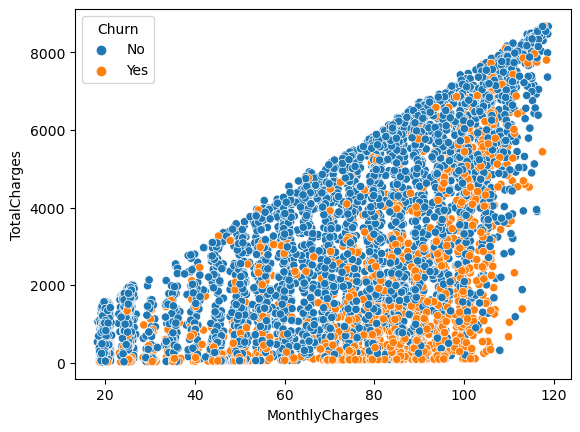

In [27]:
# Monthly charges and Totalcharges
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', data=df,hue='Churn')
plt.show()

- As MonthlyCharges increase, TotalCharges also tend to increase.

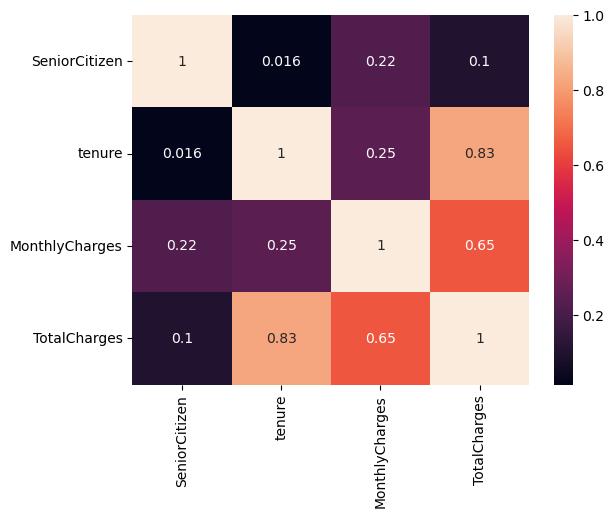

In [28]:
# Correlation heatmap
sns.heatmap(data=df.corr(),annot=True)
plt.show()

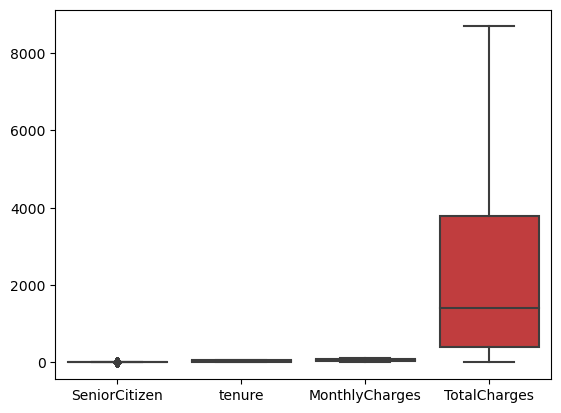

In [29]:
# Check for outliers
sns.boxplot(data=df)
plt.show()

### Data Preprocessing

#### Encoding Categorical Data

In [30]:
encoder = LabelEncoder()
for column in cat_cols:
    df[column] = encoder.fit_transform(df[column])

In [31]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [32]:
# Feature Separartion
X = df.drop('Churn',axis=1)
y = df.Churn

#### Train Test Split

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#### Handling Class Imbalance

In [34]:
smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [35]:
y_train_smote.value_counts()

1    4130
0    4130
Name: Churn, dtype: int64

#### Feature Scaling

In [36]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

### Model Training and Evaluation

In [41]:
def evaluate_model(model):
    
    # Training Model
    model.fit(X_train_scaled,y_train_smote)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    report = classification_report(y_test,y_pred)
    
    # Displaying Results
    print(f'Accuracy Score:{acc}')
    print(f'Classification Report:\n{report}')
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'Confusion Matrix for {type(model).__name__}')
    plt.show()
    
    # Kde Plot
    sns.kdeplot(y_test, label='Actual',color='b')
    sns.kdeplot(y_pred, label='Predicted',color='r')
    plt.legend()

#### Logistic Regression

Accuracy Score:0.7455579246624022
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.52      0.72      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



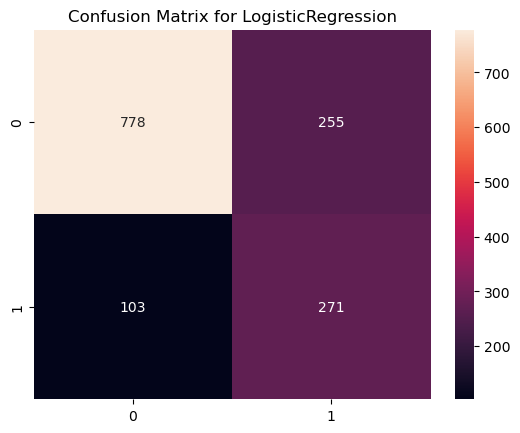

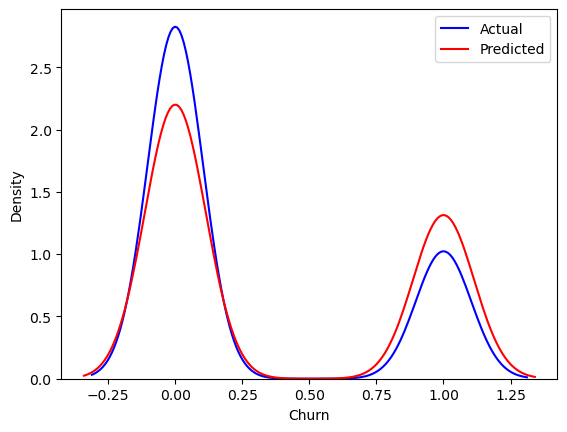

In [42]:
lr_model = LogisticRegression()
evaluate_model(lr_model)

#### KNN

Accuracy Score:0.6922530206112296
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.71      0.77      1033
           1       0.45      0.65      0.53       374

    accuracy                           0.69      1407
   macro avg       0.65      0.68      0.65      1407
weighted avg       0.74      0.69      0.71      1407



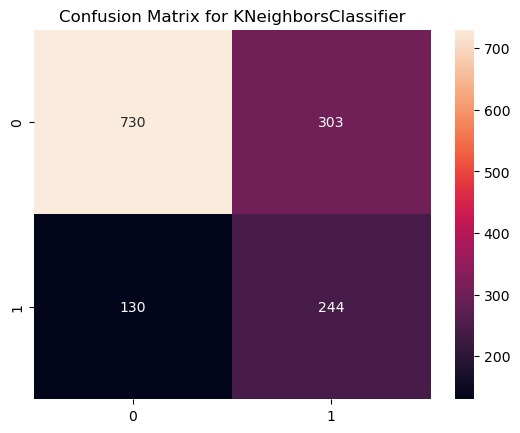

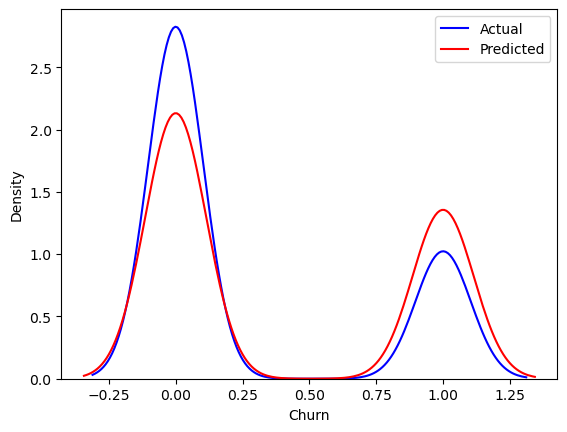

In [43]:
knn_model = KNeighborsClassifier()
evaluate_model(knn_model)

#### Naive Bayes

Accuracy Score:0.7185501066098081
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.72      0.79      1033
           1       0.48      0.72      0.58       374

    accuracy                           0.72      1407
   macro avg       0.68      0.72      0.68      1407
weighted avg       0.77      0.72      0.73      1407



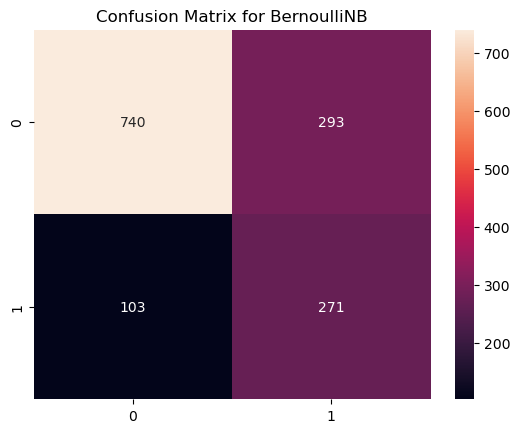

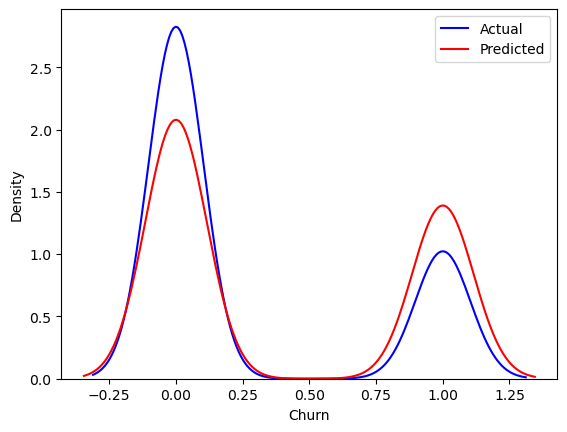

In [44]:
nb_model = BernoulliNB()
evaluate_model(nb_model)

#### SVM

Accuracy Score:0.757640369580668
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1033
           1       0.54      0.62      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.76      0.76      1407



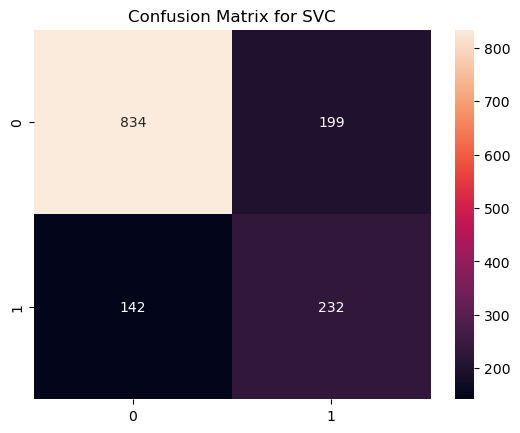

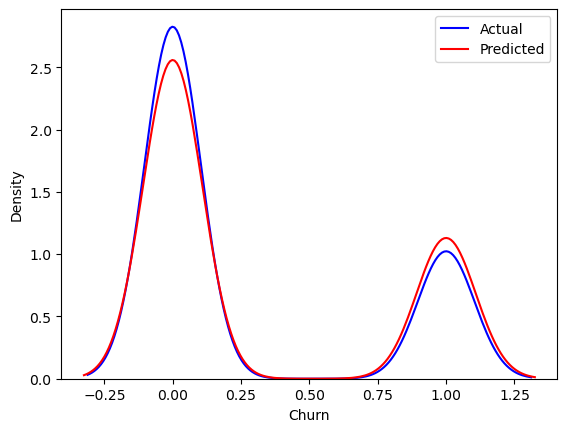

In [45]:
svc_model = SVC()
evaluate_model(svc_model)

- The Support Vector Machine (SVM) model performed the best with an accuracy of 75.76%. This shows that SVM was able to effectively identify patterns in the data and predict customer churn better than other models like Logistic Regression, KNN, and Naive Bayes.